<a href="https://colab.research.google.com/github/Froststar16/canopy-watch-hyderabad/blob/main/notebooks/02_ward_level_ndvi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Canopy Watch — Hyderabad
### Phase 2: Real GHMC boundary + ward-level NDVI

Phase 1 used a rough bounding box as a placeholder AOI. This notebook:

1. Sources the **real GHMC administrative boundary and all 150 ward boundaries** (official GHMC GIS data, via OpenCity India)
2. Loads them into Earth Engine as `FeatureCollection`s
3. Re-runs the yearly mean-NDVI trend against the **real city boundary** (replacing the Phase 1 bounding-box estimate)
4. Computes yearly mean NDVI **per ward** — the actual Phase 2 goal — to localize deforestation/growth hotspots instead of a single city-wide number
5. Saves everything to CSV + a couple of sanity-check visuals

> **A note on currency:** GHMC is partway through a High Court-mandated ward delimitation that will eventually expand it from 150 to 300 wards (gazette notification issued Dec 2025). This notebook uses the current, legally-in-force 150-ward layout. If/when the 300-ward boundaries are published as open data, swap the source URL in Section 2 — everything downstream (NDVI computation, CSV shape) stays the same.

## 1. Setup

In [1]:
!pip install geopandas geemap --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 28.9 MB/s eta 0:00:00


In [2]:
import ee
import geemap
import geopandas as gpd
import pandas as pd
import requests
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET
from shapely.geometry import Polygon, MultiPolygon

# Auth + init — use the same Cloud project as Phase 1
ee.Authenticate()
ee.Initialize(project='canopy-watch-hyderabad')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
OUTPUT_DIR = '/content/drive/MyDrive/canopy-watch-hyderabad/outputs'
DATA_DIR = '/content/drive/MyDrive/canopy-watch-hyderabad/data'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

Mounted at /content/drive


## 2. Source the real GHMC boundary + ward boundaries

Source: **OpenCity India**, "Hyderabad — Wards Info" dataset — https://data.opencity.in/dataset/hyderabad-wards-info
Original data from GHMC's own GIS (ghmc.gov.in). Public domain / open license.

Two KML files:
- `ghmc_boundary.kml` — single polygon, the overall GHMC administrative limit
- `ghmc_wards.kml` — 150 ward polygons, each tagged with `ward` (e.g. `"127-RANGAREDDY NAGAR"`), `CIRCLE`, and `ZONE`

Colab's GDAL build usually reads KML natively via geopandas. As a safety net in case your environment doesn't, the loader below falls back to a manual XML parser — tested against this exact schema, so either path gives you the same result.

In [4]:
WARDS_KML_URL = "https://data.opencity.in/dataset/15cb7d8d-eed1-4aad-8cd7-f281cbf4f94f/resource/14b033e3-3721-4149-8326-cc29420e062e/download/ghmc_wards.kml"
BOUNDARY_KML_URL = "https://data.opencity.in/dataset/15cb7d8d-eed1-4aad-8cd7-f281cbf4f94f/resource/bc818c3d-9c7c-4047-a451-ba463d9710b2/download/fc191d52-4b8a-4e2f-8fb8-0359746037d7.kml"

def download(url, path):
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    with open(path, 'wb') as f:
        f.write(r.content)
    return path

wards_kml_path = download(WARDS_KML_URL, f'{DATA_DIR}/ghmc_wards.kml')
boundary_kml_path = download(BOUNDARY_KML_URL, f'{DATA_DIR}/ghmc_boundary.kml')
print("Downloaded both KML files.")

Downloaded both KML files.


In [5]:
NS = {"kml": "http://www.opengis.net/kml/2.2"}

def load_kml_as_gdf(path):
    """Robust KML loader: try geopandas/GDAL first, fall back to manual XML parsing."""
    for kwargs in ({}, {"driver": "KML"}, {"driver": "LIBKML"}):
        try:
            gdf = gpd.read_file(path, **kwargs)
            if len(gdf) > 0:
                print(f"Loaded '{path}' via geopandas ({kwargs or 'default driver'}): {len(gdf)} feature(s)")
                return gdf
        except Exception:
            pass

    print(f"GDAL KML driver unavailable — falling back to manual parser for '{path}'")
    tree = ET.parse(path)
    root = tree.getroot()
    records, geoms = [], []
    for placemark in root.iter("{http://www.opengis.net/kml/2.2}Placemark"):
        props = {}
        for sd in placemark.iter("{http://www.opengis.net/kml/2.2}SimpleData"):
            props[sd.get("name")] = sd.text
        polygons = []
        for poly_el in placemark.iter("{http://www.opengis.net/kml/2.2}Polygon"):
            outer = poly_el.find(".//kml:outerBoundaryIs/kml:LinearRing/kml:coordinates", NS)
            if outer is None or not outer.text:
                continue
            ring = []
            for triple in outer.text.strip().split():
                lon, lat = map(float, triple.split(",")[:2])
                ring.append((lon, lat))
            if len(ring) >= 4:
                polygons.append(Polygon(ring))
        if not polygons:
            continue
        geom = polygons[0] if len(polygons) == 1 else MultiPolygon(polygons)
        geoms.append(geom)
        records.append(props if props else {"id": placemark.get("id")})
    gdf = gpd.GeoDataFrame(records, geometry=geoms, crs="EPSG:4326")
    print(f"Loaded '{path}' via manual parser: {len(gdf)} feature(s)")
    return gdf

wards_gdf = load_kml_as_gdf(wards_kml_path)
boundary_gdf = load_kml_as_gdf(boundary_kml_path)

wards_gdf = wards_gdf.set_crs("EPSG:4326", allow_override=True)
boundary_gdf = boundary_gdf.set_crs("EPSG:4326", allow_override=True)

print(f"\nWards: {len(wards_gdf)}  |  Boundary features: {len(boundary_gdf)}")
wards_gdf[['ward', 'CIRCLE', 'ZONE']].head()

Loaded '/content/drive/MyDrive/canopy-watch-hyderabad/data/ghmc_wards.kml' via geopandas (default driver): 155 feature(s)
Loaded '/content/drive/MyDrive/canopy-watch-hyderabad/data/ghmc_boundary.kml' via geopandas (default driver): 1 feature(s)

Wards: 155  |  Boundary features: 1


,ward,CIRCLE,ZONE
0,127-RANGAREDDY NAGAR,25-QUTUBULLAPUR,KUKATPALLY ZONE
1,119-OLD BOWENPALLY,24-KUKATPALLY,KUKATPALLY ZONE
2,145-SEETHAPHALMANDI,29-SECUNDERABAD,SECUNDERABAD ZONE
3,146-BOUDHA NAGAR,29-SECUNDERABAD,SECUNDERABAD ZONE
4,147-BANSILALPET,30-BEGUMPET,SECUNDERABAD ZONE


In [6]:
# Split "127-RANGAREDDY NAGAR" into ward number + name for easier grouping/joins later
split_ward = wards_gdf['ward'].str.split('-', n=1, expand=True)
wards_gdf['ward_no'] = split_ward[0].str.strip()
wards_gdf['ward_name'] = split_ward[1].str.strip()

wards_gdf = wards_gdf[['ward_no', 'ward_name', 'CIRCLE', 'ZONE', 'geometry']].copy()
wards_gdf.columns = ['ward_no', 'ward_name', 'circle', 'zone', 'geometry']
wards_gdf.head()

,ward_no,ward_name,circle,zone,geometry
0,127,RANGAREDDY NAGAR,25-QUTUBULLAPUR,KUKATPALLY ZONE,"MULTIPOLYGON (((78.45031 17.48797, 78.45029 17..."
1,119,OLD BOWENPALLY,24-KUKATPALLY,KUKATPALLY ZONE,"MULTIPOLYGON (((78.47869 17.48565, 78.47943 17..."
2,145,SEETHAPHALMANDI,29-SECUNDERABAD,SECUNDERABAD ZONE,"MULTIPOLYGON (((78.52062 17.4268, 78.52074 17...."
3,146,BOUDHA NAGAR,29-SECUNDERABAD,SECUNDERABAD ZONE,"MULTIPOLYGON (((78.52018 17.4193, 78.51998 17...."
4,147,BANSILALPET,30-BEGUMPET,SECUNDERABAD ZONE,"MULTIPOLYGON (((78.50605 17.43299, 78.50621 17..."


## 3. Load into Earth Engine + sanity-check against the Phase 1 bounding box

Government-sourced ward boundary data is very often topologically messy — self-touching rings, bowtie self-intersections, inconsistent winding order — even though GDAL happily reads it. Earth Engine's GeoJSON parser is much stricter than GDAL's, so it rejects the *entire* `FeatureCollection` if even one ward's geometry is malformed. The cell below repairs invalid geometries (`make_valid` + consistent ring orientation) before conversion, and converts feature-by-feature so that if anything still can't convert, you get told exactly which ward — instead of one opaque error for the whole collection.

(Also: the live dataset currently has 155 ward features, not the 150 usually cited — GHMC's ward count has shifted around at the margins over the last couple of years. Not a bug, just how the source data is right now.)

In [7]:
from shapely.validation import make_valid
from shapely.geometry.polygon import orient
from shapely.geometry import mapping

def _polygons_only(geom):
    """Flatten a Polygon/MultiPolygon/GeometryCollection down to a list of Polygons."""
    if geom.geom_type == 'Polygon':
        return [geom]
    elif geom.geom_type == 'MultiPolygon':
        return list(geom.geoms)
    elif geom.geom_type == 'GeometryCollection':
        out = []
        for g in geom.geoms:
            out.extend(_polygons_only(g))
        return out
    return []

def clean_geometry(geom):
    """Repair invalid geometry and enforce GeoJSON-compliant ring winding (CCW exterior)."""
    if geom is None or geom.is_empty:
        return None
    if not geom.is_valid:
        geom = make_valid(geom)  # splits self-intersections into a valid Multi(Polygon)/GeometryCollection
    polys = [p for p in _polygons_only(geom) if p.area > 0]
    if not polys:
        return None
    polys = [orient(p, sign=1.0) for p in polys]
    return polys[0] if len(polys) == 1 else MultiPolygon(polys)

def report_and_clean(gdf, name):
    n_before_invalid = (~gdf.geometry.is_valid).sum()
    gdf = gdf.copy()
    gdf['geometry'] = gdf.geometry.apply(clean_geometry)
    n_dropped = gdf['geometry'].isna().sum()
    gdf = gdf[gdf['geometry'].notna()].reset_index(drop=True)
    print(f"{name}: {n_before_invalid} invalid geometrie(s) repaired, {n_dropped} unrepairable feature(s) dropped, {len(gdf)} remain.")
    return gdf

wards_gdf = report_and_clean(wards_gdf, 'wards_gdf')

wards_gdf: 0 invalid geometrie(s) repaired, 0 unrepairable feature(s) dropped, 155 remain.


In [8]:
def gdf_to_ee_safe(gdf):
    """Convert feature-by-feature so one bad geometry doesn't sink the whole collection."""
    features, failed = [], []
    prop_cols = [c for c in gdf.columns if c != 'geometry']
    for idx, row in gdf.iterrows():
        try:
            ee_geom = ee.Geometry(mapping(row.geometry))
            props = {c: row[c] for c in prop_cols if row[c] == row[c]}  # drop NaNs
            features.append(ee.Feature(ee_geom, props))
        except Exception as e:
            failed.append((idx, row.get('ward_no', idx), str(e)))
    if failed:
        print(f"WARNING: {len(failed)} feature(s) still failed to convert and were skipped:")
        for idx, ident, err in failed:
            print(f"  row {idx} (ward_no={ident}): {err}")
    else:
        print(f"All {len(features)} features converted successfully.")
    return ee.FeatureCollection(features)

wards_ee = gdf_to_ee_safe(wards_gdf)

# Use the dissolved union of the (now-valid) ward polygons as the citywide boundary,
# rather than the separately-sourced ghmc_boundary.kml. The wards already tile the
# full city, and this sidesteps whatever geometry quirk that standalone file has
# that EE won't ingest even after repair -- one boundary source, always consistent
# with the sum of the wards.
ghmc_geometry = wards_ee.geometry()

All 155 features converted successfully.


In [9]:
# The Phase 1 placeholder — swap in your actual Phase 1 coordinates if different
phase1_bbox = ee.Geometry.Rectangle([78.30, 17.25, 78.65, 17.55])

Map = geemap.Map()
Map.centerObject(ghmc_geometry, 10)
Map.addLayer(phase1_bbox, {'color': 'red'}, 'Phase 1 placeholder bbox')
Map.addLayer(ghmc_geometry, {'color': 'blue'}, 'Real GHMC boundary (union of wards)')
Map.addLayer(wards_ee.style(color='black', fillColor='00000000', width=1), {}, 'Wards')
Map

Map(center=[17.427059933332384, 78.45485027014189], controls=(WidgetControl(options=['position', 'transparent_…

You should see the blue GHMC boundary sitting well inside the red placeholder box — the bbox was including a fair amount of non-GHMC area (and missing some GHMC area on the edges), which is exactly why Phase 1's numbers were a sanity check rather than a real reading.

## 4. NDVI pipeline (Sentinel-2, cloud-masked)

Same core function as Phase 1 — if your Phase 1 cloud-masking differed, swap this for your original so the two runs stay comparable.

In [10]:
def mask_s2_clouds(image):
    qa = image.select('QA60')
    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11
    mask = qa.bitwiseAnd(cloud_bit_mask).eq(0).And(qa.bitwiseAnd(cirrus_bit_mask).eq(0))
    return image.updateMask(mask).divide(10000)

def yearly_ndvi_image(year, region):
    start = f'{year}-01-01'
    end = f'{year}-12-31'
    collection = (ee.ImageCollection('COPERNICUS/S2_HARMONIZED')
                  .filterDate(start, end)
                  .filterBounds(region)
                  .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30))
                  .map(mask_s2_clouds))
    composite = collection.median()
    ndvi = composite.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return ndvi

YEARS = list(range(2016, 2027))  # Sentinel-2 archive starts mid-2015; 2016 on is clean full-year coverage

## 5. Citywide yearly mean NDVI — real GHMC boundary

In [11]:
citywide_rows = []
for year in YEARS:
    ndvi = yearly_ndvi_image(year, ghmc_geometry)
    stat = ndvi.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=ghmc_geometry,
        scale=10,
        maxPixels=1e10,
        bestEffort=True
    ).get('NDVI')
    value = stat.getInfo()
    citywide_rows.append({'year': year, 'mean_ndvi': value})
    print(year, value)

citywide_df = pd.DataFrame(citywide_rows)
citywide_df.to_csv(f'{OUTPUT_DIR}/hyderabad_ndvi_yearly_realboundary.csv', index=False)
citywide_df

2016 0.21038296613352891
2017 0.20131008317123053
2018 0.1664100900842011
2019 0.16938998883466422
2020 0.18521172081311268
2021 0.17243782127170246
2022 0.1631214435557268
2023 0.19053755851791684
2024 0.15553165665573748
2025 0.1698472689630927
2026 0.14605707980790403


,year,mean_ndvi
0,2016,0.210383
1,2017,0.201310
2,2018,0.166410
3,2019,0.169390
4,2020,0.185212
5,2021,0.172438
6,2022,0.163121
7,2023,0.190538
8,2024,0.155532
9,2025,0.169847


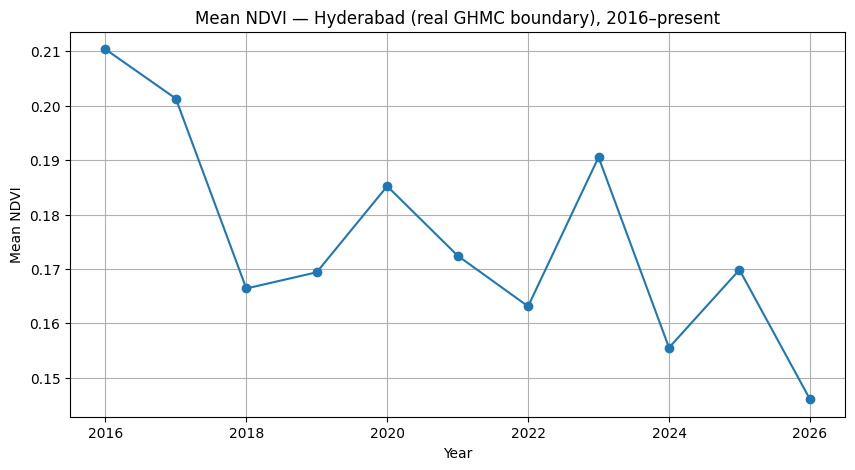

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(citywide_df['year'], citywide_df['mean_ndvi'], marker='o')
plt.title('Mean NDVI — Hyderabad (real GHMC boundary), 2016–present')
plt.xlabel('Year')
plt.ylabel('Mean NDVI')
plt.grid(True)
plt.savefig(f'{OUTPUT_DIR}/ndvi_trend_realboundary.png', dpi=150)
plt.show()

## 6. Ward-level yearly NDVI — the actual Phase 2 goal

For each year, compute the annual NDVI composite once, then use `reduceRegions` to get the mean NDVI for **all 150 wards in a single server-side call** (much faster than looping per-ward client-side).

In [13]:
ward_rows = []
for year in YEARS:
    ndvi = yearly_ndvi_image(year, ghmc_geometry)
    stats = ndvi.reduceRegions(
        collection=wards_ee,
        reducer=ee.Reducer.mean(),
        scale=10,
        tileScale=4
    )
    features = stats.getInfo()['features']
    for f in features:
        props = f['properties']
        ward_rows.append({
            'year': year,
            'ward_no': props.get('ward_no'),
            'ward_name': props.get('ward_name'),
            'circle': props.get('circle'),
            'zone': props.get('zone'),
            'mean_ndvi': props.get('mean')
        })
    print(f'{year}: {len(features)} wards processed')

ward_df = pd.DataFrame(ward_rows)
ward_df.to_csv(f'{OUTPUT_DIR}/hyderabad_ndvi_by_ward.csv', index=False)
ward_df.head()

2016: 155 wards processed
2017: 155 wards processed


2018: 155 wards processed
2019: 155 wards processed
2020: 155 wards processed
2021: 155 wards processed
2022: 155 wards processed
2023: 155 wards processed
2024: 155 wards processed
2025: 155 wards processed
2026: 155 wards processed


,year,ward_no,ward_name,circle,zone,mean_ndvi
0,2016,127,RANGAREDDY NAGAR,25-QUTUBULLAPUR,KUKATPALLY ZONE,0.149990
1,2016,119,OLD BOWENPALLY,24-KUKATPALLY,KUKATPALLY ZONE,0.151146
2,2016,145,SEETHAPHALMANDI,29-SECUNDERABAD,SECUNDERABAD ZONE,0.102412
3,2016,146,BOUDHA NAGAR,29-SECUNDERABAD,SECUNDERABAD ZONE,0.089863
4,2016,147,BANSILALPET,30-BEGUMPET,SECUNDERABAD ZONE,0.152914


## 7. Quick sanity check — biggest NDVI gainers/losers by ward

First year vs. most recent year with complete data, per ward. This is just a sanity check on the pipeline, not the final hotspot analysis — Phase 3 will add the LST correlation before drawing real conclusions.

In [14]:
first_year, last_year = ward_df['year'].min(), ward_df['year'].max()

pivot = ward_df.pivot_table(index=['ward_no', 'ward_name', 'zone'], columns='year', values='mean_ndvi')
pivot['change'] = pivot[last_year] - pivot[first_year]
change_sorted = pivot.sort_values('change')

print(f"Biggest NDVI declines, {first_year} -> {last_year}:")
display(change_sorted.head(10)[[first_year, last_year, 'change']])

print(f"\nBiggest NDVI gains, {first_year} -> {last_year}:")
display(change_sorted.tail(10)[[first_year, last_year, 'change']])

Biggest NDVI declines, 2016 -> 2026:


,,year,2016,2026,change
ward_no,ward_name,zone,,,
10,UPPAL,L.B.NAGAR ZONE,0.247656,0.131762,-0.115894
11,NAGOLE,L.B.NAGAR ZONE,0.268553,0.154478,-0.114075
41,KANCHANBAGH,CHARMINAR ZONE,0.315416,0.202057,-0.113359
105,GACHIBOWLI,SERILINGAMPALLY ZONE,0.270701,0.170804,-0.099897
113,PATANCHERUVU,SERILINGAMPALLY ZONE,0.266251,0.169033,-0.097218
13,HAYATHNAGAR,L.B.NAGAR ZONE,0.255814,0.159808,-0.096005
60,RAJENDRANAGAR,CHARMINAR ZONE,0.299364,0.207635,-0.091729
83,AMBERPET,SECUNDERABAD ZONE,0.222435,0.131027,-0.091408
9,RAMANTHAPUR,L.B.NAGAR ZONE,0.214888,0.123806,-0.091083



Biggest NDVI gains, 2016 -> 2026:


,,year,2016,2026,change
ward_no,ward_name,zone,,,
128,CHINTAL,KUKATPALLY ZONE,0.236974,0.221663,-0.015311
76,MALLEPALLY,KHAIRATHABAD ZONE,0.097030,0.083980,-0.013051
32,PATHER GATTI,CHARMINAR ZONE,0.095419,0.082721,-0.012698
80,KACHIGUDA(Barkathpura),SECUNDERABAD ZONE,0.113288,0.100910,-0.012378
49,GANSIBAZAR,CHARMINAR ZONE,0.108055,0.096407,-0.011649
127,RANGAREDDY NAGAR,KUKATPALLY ZONE,0.149990,0.138538,-0.011452
148,RAMGOPALPET,SECUNDERABAD ZONE,0.114723,0.103538,-0.011184
91,KHAIRTABAD,KHAIRATHABAD ZONE,0.069038,0.059001,-0.010037
88,BHOLAKPUR,SECUNDERABAD ZONE,0.101134,0.091490,-0.009645


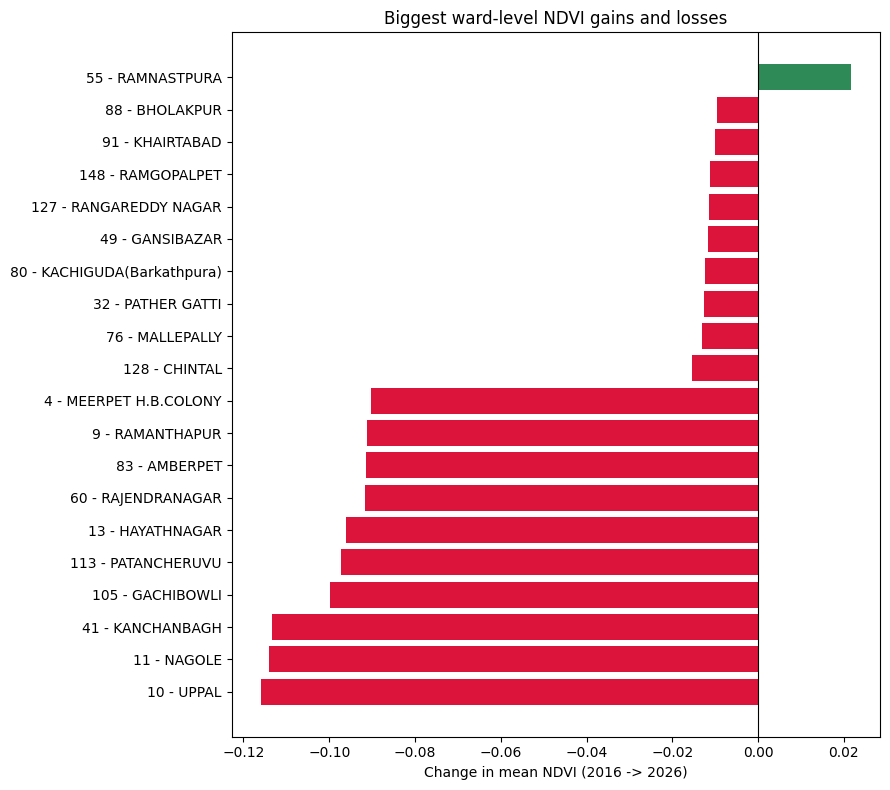

In [15]:
top_change = pd.concat([change_sorted.head(10), change_sorted.tail(10)])
top_change = top_change.reset_index()
top_change['label'] = top_change['ward_no'] + ' - ' + top_change['ward_name']

plt.figure(figsize=(9, 8))
colors = ['crimson' if c < 0 else 'seagreen' for c in top_change['change']]
plt.barh(top_change['label'], top_change['change'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel(f'Change in mean NDVI ({first_year} -> {last_year})')
plt.title('Biggest ward-level NDVI gains and losses')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/ward_ndvi_change.png', dpi=150)
plt.show()

## Next steps

- Copy `data/ghmc_wards.kml` and `data/ghmc_boundary.kml` (or convert to GeoJSON — see below) into the repo under `data/` so the boundary is version-controlled, not just re-downloaded each run.
- Move to Phase 3: pull the Landsat thermal band, compute land surface temperature (LST), correlate against this ward-level NDVI table (urban heat island analysis).
- Once both are working, source public Haritha Haram sapling-count data and compare against what the satellite actually shows, per ward.